# Binary Classification Model Tuning

In the previous notebook, I built baseline binary classification models to predict whether a patient had at least one asthma exacerbation after treatment start.

The baseline results showed that:

- The dummy classifier and standard logistic regression achieved high accuracy but failed to identify positive cases.
- Class-weighted logistic regression improved recall but produced many false positives.
- Random Forest did not perform well for minority-class detection in the baseline setup.

In this notebook, I will improve the modeling workflow by tuning models more carefully using the training data. I will avoid choosing model settings directly from the test set, because the test set should represent unseen data for final evaluation.

## Modeling Plan

The main goals of this notebook are:

1. Load the processed train-test datasets.
2. Use cross-validation on the training data.
3. Tune logistic regression regularization strength.
4. Tune the classification threshold using cross-validated predicted probabilities.
5. Tune a Random Forest model using selected hyperparameters.
6. Compare tuned models.
7. Evaluate the final selected model on the test set.

The most important metrics for this imbalanced classification task are recall, precision, F1-score, ROC-AUC, and PR-AUC. Accuracy will be reported but will not be the main decision metric.

In [1]:
# Importing libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")


## Load Processed Data

I will load the processed train-test datasets created in the preprocessing notebook.

The test set will not be used for model tuning. It will only be used at the end for final model evaluation.

In [2]:
# Load processed files

X_train = pd.read_csv("../data/processed/X_train_log.csv")
X_test = pd.read_csv("../data/processed/X_test_log.csv")

y_train = pd.read_csv("../data/processed/y_binary_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_binary_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (14572, 16)
X_test shape: (3643, 16)
y_train shape: (14572,)
y_test shape: (3643,)


In [3]:
# To check class balance

class_balance = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "train_percent": y_train.value_counts(normalize=True).sort_index() * 100,
    "test_count": y_test.value_counts().sort_index(),
    "test_percent": y_test.value_counts(normalize=True).sort_index() * 100
})

class_balance


,train_count,train_percent,test_count,test_percent
had_exacerbation,,,,
0,12899,88.5191,3225,88.5259
1,1673,11.4809,418,11.4741


## Evaluation Function

To compare models consistently, I will define an evaluation function.

This function calculates:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

For this project, recall and PR-AUC are especially important because the positive class is small and clinically meaningful.

In [4]:
# Evaluation function

def evaluate_classifier(model_name, y_true, y_pred, y_proba=None):
    """
    Evaluate a binary classification model using common metrics.
    Positive class = 1, meaning at least one post-index exacerbation.
    """
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }
    
    if y_proba is not None:
        results["roc_auc"] = roc_auc_score(y_true, y_proba)
        results["pr_auc"] = average_precision_score(y_true, y_proba)
    else:
        results["roc_auc"] = np.nan
        results["pr_auc"] = np.nan
    
    return pd.DataFrame([results])
    

## Cross-Validation Setup

I will use stratified 5-fold cross-validation on the training data.

Stratified cross-validation is useful here because it preserves the class distribution in each fold. This is important because only about 11.5% of patients had at least one exacerbation.

In [11]:
# CV setup

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=22
)

cv


StratifiedKFold(n_splits=5, random_state=22, shuffle=True)

## Tuned Logistic Regression

In the baseline notebook, class-weighted logistic regression gave the best recall among the simple models.

Here, I will tune the regularization strength `C` using cross-validation. The model will use:

- Standard scaling
- Logistic regression
- Balanced class weights

The parameter `C` controls regularization strength. Smaller values apply stronger regularization, while larger values apply weaker regularization.


In [14]:
# Logistic Regression Grid Search

log_reg_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=22,
            class_weight="balanced",
            solver="saga"
        ))
    ]
)

log_reg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0, 0.5, 1]
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

log_reg_grid.fit(X_train, y_train)

print("Best parameters:", log_reg_grid.best_params_)
print("Best cross-validated PR-AUC:", log_reg_grid.best_score_)


Best parameters: {'model__C': 0.1, 'model__l1_ratio': 1}
Best cross-validated PR-AUC: 0.14441294773374924


In [15]:
# Cross-Validated Probabilities for Best Logistic Model

best_log_reg = log_reg_grid.best_estimator_

log_reg_cv_proba = cross_val_predict(
    best_log_reg,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

pd.Series(log_reg_cv_proba).describe()

count   14572.0000
mean        0.4930
std         0.0655
min         0.0757
25%         0.4509
50%         0.4936
75%         0.5349
max         0.7796
dtype: float64

## Threshold Tuning Using Cross-Validated Predictions

Instead of selecting a threshold directly from the test set, I will use cross-validated predicted probabilities from the training data.

This gives a more realistic way to choose a classification threshold before evaluating the final model on the test set.

In [16]:
# Threshold Search on Training CV Predictions

thresholds = np.arange(0.05, 0.51, 0.01)

threshold_tuning_results = []

for threshold in thresholds:
    y_train_pred_threshold = (log_reg_cv_proba >= threshold).astype(int)
    
    threshold_tuning_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_train, y_train_pred_threshold),
        "precision": precision_score(y_train, y_train_pred_threshold, zero_division=0),
        "recall": recall_score(y_train, y_train_pred_threshold, zero_division=0),
        "f1": f1_score(y_train, y_train_pred_threshold, zero_division=0)
    })

threshold_tuning_results = pd.DataFrame(threshold_tuning_results)

threshold_tuning_results.sort_values("f1", ascending=False).head(10)



,threshold,accuracy,precision,recall,f1
44,0.4900,0.5049,0.1352,0.6139,0.2216
45,0.5000,0.5530,0.1382,0.5529,0.2212
43,0.4800,0.4533,0.1320,0.6748,0.2209
42,0.4700,0.4076,0.1299,0.7304,0.2206
41,0.4600,0.3647,0.1274,0.7753,0.2189
40,0.4500,0.3196,0.1252,0.8231,0.2174
39,0.4400,0.2790,0.1230,0.8613,0.2153
38,0.4300,0.2449,0.1211,0.8912,0.2132
37,0.4200,0.2136,0.1190,0.9139,0.2106
36,0.4100,0.1912,0.1181,0.9342,0.2096


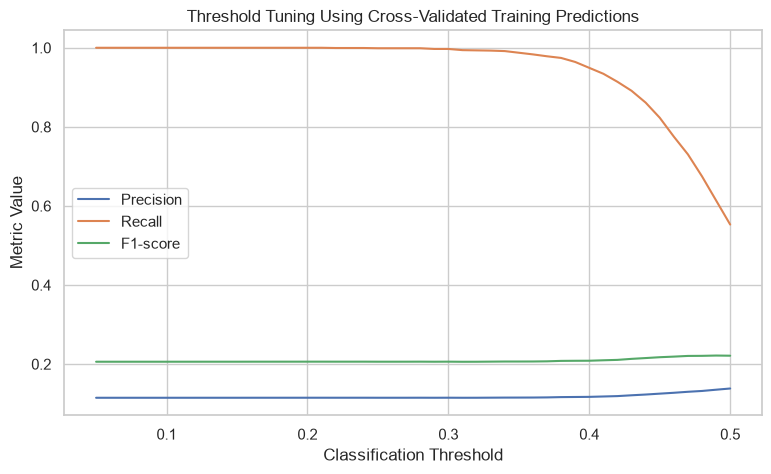

In [17]:
# Plotting Threshold Results

plt.figure(figsize=(9, 5))

plt.plot(threshold_tuning_results["threshold"], threshold_tuning_results["precision"], label="Precision")
plt.plot(threshold_tuning_results["threshold"], threshold_tuning_results["recall"], label="Recall")
plt.plot(threshold_tuning_results["threshold"], threshold_tuning_results["f1"], label="F1-score")

plt.title("Threshold Tuning Using Cross-Validated Training Predictions")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.show()

In [18]:
# To Choose Best F1 Threshold

best_threshold_row = threshold_tuning_results.loc[
    threshold_tuning_results["f1"].idxmax()
]

best_threshold = best_threshold_row["threshold"]

best_threshold_row


threshold   0.4900
accuracy    0.5049
precision   0.1352
recall      0.6139
f1          0.2216
Name: 44, dtype: float64

## Observation: Logistic Regression Tuning

The tuned logistic regression model used class weighting to address the imbalanced outcome. I tuned the regularization strength `C` and the regularization type using cross-validation on the training data.

The best cross-validated PR-AUC was about **0.1444**, which is only modestly higher than the baseline positive-class rate. This suggests that the available predictors contain some signal, but the binary exacerbation prediction problem remains difficult.

The best parameters were:

- `C`: **0.1**
- `l1_ratio`: **1**

This indicates that a more strongly regularized, L1-like logistic regression model performed best among the tested settings.

The cross-validated predicted probabilities were centered around **0.49**, with a median of about **0.4936**. This is expected because the model used `class_weight="balanced"`, which increases the influence of the minority class during training.

Using cross-validated predictions from the training data, the best F1-score among the tested thresholds occurred at threshold **0.49**. At this threshold:

- Accuracy = **0.5049**
- Precision = **0.1352**
- Recall = **0.6139**
- F1-score = **0.2216**

This threshold was selected using training data only. The test set has not been used for threshold selection.


## Final Test Evaluation: Tuned Logistic Regression

After selecting the logistic regression hyperparameters and threshold using only the training data, I will now evaluate the tuned model on the held-out test set.

This is important because the test set represents unseen data and gives a more honest estimate of model performance.

In [19]:
# Test evaluation

# Best tuned logistic regression model from grid search
best_log_reg = log_reg_grid.best_estimator_

# Fit best model on the full training set
best_log_reg.fit(X_train, y_train)

# Predict probabilities on the test set
log_reg_tuned_test_proba = best_log_reg.predict_proba(X_test)[:, 1]

# Apply selected threshold from training CV
log_reg_tuned_test_pred = (log_reg_tuned_test_proba >= best_threshold).astype(int)

# Evaluate final tuned logistic regression model
log_reg_tuned_test_results = evaluate_classifier(
    model_name="Tuned Logistic Regression",
    y_true=y_test,
    y_pred=log_reg_tuned_test_pred,
    y_proba=log_reg_tuned_test_proba
)

log_reg_tuned_test_results



,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Tuned Logistic Regression,0.5059,0.1344,0.6077,0.2201,0.5615,0.1347


In [20]:
# Confusion matrix

confusion_matrix(y_test, log_reg_tuned_test_pred)


array([[1589, 1636],
       [ 164,  254]])

In [21]:
# Classification report

print(classification_report(y_test, log_reg_tuned_test_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.91      0.49      0.64      3225
           1       0.13      0.61      0.22       418

    accuracy                           0.51      3643
   macro avg       0.52      0.55      0.43      3643
weighted avg       0.82      0.51      0.59      3643



## Observation: Final Test Evaluation of Tuned Logistic Regression

The tuned logistic regression model was evaluated on the held-out test set after hyperparameter tuning and threshold selection were performed using only the training data.

The final test results were:

- Accuracy: **0.5059**
- Precision: **0.1344**
- Recall: **0.6077**
- F1-score: **0.2201**
- ROC-AUC: **0.5615**
- PR-AUC: **0.1347**

The confusion matrix shows that the model identified **254 out of 418** patients who actually had at least one post-index exacerbation. This corresponds to a recall of **60.77%**.

However, the model also produced **1,636 false positives**, meaning many patients were classified as high risk even though they did not have an exacerbation. This explains the low precision of **13.44%**.

Compared with the baseline standard logistic regression, the tuned model is much better at identifying positive cases. However, the low precision and modest PR-AUC indicate that this remains a difficult prediction problem.

From a clinical screening perspective, this type of model may be useful if the goal is to identify more potentially at-risk patients for follow-up. However, it would not be reliable enough as a stand-alone decision-making tool because of the high number of false positives.


In [22]:
# Baseline results from previous notebook for comparison
baseline_comparison = pd.DataFrame({
    "model": [
        "Dummy Classifier",
        "Logistic Regression",
        "Logistic Regression Balanced",
        "Random Forest Balanced",
        "Tuned Logistic Regression"
    ],
    "accuracy": [
        0.8853,
        0.8853,
        0.5561,
        0.8729,
        log_reg_tuned_test_results.loc[0, "accuracy"]
    ],
    "precision": [
        0.0000,
        0.0000,
        0.1373,
        0.1186,
        log_reg_tuned_test_results.loc[0, "precision"]
    ],
    "recall": [
        0.0000,
        0.0000,
        0.5431,
        0.0167,
        log_reg_tuned_test_results.loc[0, "recall"]
    ],
    "f1": [
        0.0000,
        0.0000,
        0.2192,
        0.0294,
        log_reg_tuned_test_results.loc[0, "f1"]
    ],
    "roc_auc": [
        0.5000,
        0.5631,
        0.5621,
        0.5170,
        log_reg_tuned_test_results.loc[0, "roc_auc"]
    ],
    "pr_auc": [
        0.1147,
        0.1354,
        0.1349,
        0.1235,
        log_reg_tuned_test_results.loc[0, "pr_auc"]
    ]
})

baseline_comparison


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Dummy Classifier,0.8853,0.0000,0.0000,0.0000,0.5000,0.1147
1,Logistic Regression,0.8853,0.0000,0.0000,0.0000,0.5631,0.1354
2,Logistic Regression Balanced,0.5561,0.1373,0.5431,0.2192,0.5621,0.1349
3,Random Forest Balanced,0.8729,0.1186,0.0167,0.0294,0.5170,0.1235
4,Tuned Logistic Regression,0.5059,0.1344,0.6077,0.2201,0.5615,0.1347


## Comparison With Baseline Models

Compared with the baseline models from the previous notebook, the tuned logistic regression model achieved the highest recall.

The recall improved from **0.5431** in the baseline class-weighted logistic regression model to **0.6077** in the tuned logistic regression model.

The F1-score remained similar, changing from **0.2192** to **0.2201**. This suggests that tuning mainly improved recall, but precision remained low.

The PR-AUC remained modest at **0.1347**, only slightly higher than the positive-class prevalence in the test set. This indicates that the predictors provide limited separation between patients with and without exacerbations.

Overall, tuned logistic regression is currently the best model for identifying positive cases, but the overall predictive signal is still weak.
